# Regression Variants for the PADD Stock Model

This notebook tests alternative regression formulations designed to improve next-month PADD crude-stock forecasts without introducing excessive flexibility. Every candidate uses the same 10-fold expanding-window cross-validation and identical test months. Future observations never enter an earlier training fold.

The comparison includes level and stock-change multiple linear regressions, seasonal features, degree-two polynomial regression, and quadratic splines. Persistence is retained as the minimum-complexity benchmark.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler

from us_snd_model import DEFAULT_EIA_FILE, FEATURE_COLUMNS, PADD_NAMES, load_eia_padd

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
N_SPLITS = 10

## Feature construction

In addition to the signed balance components, the alternative formulations may use:

- the previous month's observed stock change, which is known at forecast time;
- the five-term fundamental balance; and
- sine/cosine month-of-year terms for smooth seasonality.

All rolling features are backward-looking within each PADD. The target stock change is `Stock_t+1 - Stock_t`. Predicting changes directly makes persistence equivalent to forecasting a zero change and prevents absolute stock levels from dominating the fit.

In [2]:
data = load_eia_padd(DEFAULT_EIA_FILE).sort_values(['padd', 'month']).copy()
data['stock_change_target_kb'] = data['stock_t1_actual_kb'] - data['stock_t_kb']
data['stock_change_lag1_kb'] = data.groupby('padd')['stock_t_kb'].diff()
data['month_sin'] = np.sin(2 * np.pi * data['month'].dt.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'].dt.month / 12)
data = (
    data.dropna(subset=FEATURE_COLUMNS + [
        'stock_t1_actual_kb', 'stock_change_target_kb', 'stock_change_lag1_kb'
    ])
    .reset_index(drop=True)
)
data.groupby(['padd', 'padd_name']).agg(
    start=('month', 'min'), end=('month', 'max'), observations=('month', 'size')
).reset_index()

,padd,padd_name,start,end,observations
0,1,East Coast,2007-02-01,2026-04-01,231
1,2,Midwest,2007-02-01,2026-04-01,231
2,3,Gulf Coast,2007-02-01,2026-04-01,231
3,4,Rocky Mountain,2007-02-01,2026-04-01,231
4,5,West Coast,2007-02-01,2026-04-01,231


## Candidate regression specifications

The model structures and regularization strengths are fixed before viewing results:

1. **Physical level MLR:** the existing constrained multiple linear level model.
2. **Change MLR:** an unregularized linear model of stock changes using signed flows and the lagged stock change.
3. **Seasonal ridge MLR:** adds smooth month-of-year terms and uses ridge shrinkage after fold-local scaling.
4. **Polynomial ridge:** degree-two terms only, restricted to three economically meaningful predictors and strongly regularized.
5. **Spline ridge:** quadratic splines with only four knots on the balance and lagged change, followed by ridge shrinkage.

Degree is capped at two, knot count is low, and every flexible specification is regularized. No hyperparameter search is performed against the outer CV folds.

In [3]:
flow_features = ['production_kb', 'demand_outflow_kb', 'imports_kb', 'exports_outflow_kb']
change_features = flow_features + ['stock_change_lag1_kb']
seasonal_features = change_features + ['month_sin', 'month_cos']

specifications = {
    'Physical level MLR': {
        'estimator': LinearRegression(positive=True),
        'features': FEATURE_COLUMNS, 'target': 'level',
    },
    'Change MLR': {
        'estimator': LinearRegression(),
        'features': change_features, 'target': 'change',
    },
    'Seasonal ridge MLR': {
        'estimator': Pipeline([
            ('scale', StandardScaler()), ('ridge', Ridge(alpha=10.0)),
        ]),
        'features': seasonal_features, 'target': 'change',
    },
    'Polynomial ridge (degree 2)': {
        'estimator': Pipeline([
            ('scale', StandardScaler()),
            ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
            ('ridge', Ridge(alpha=25.0)),
        ]),
        'features': ['fundamental_balance_kb', 'stock_change_lag1_kb', 'stock_t_kb'],
        'target': 'change',
    },
    'Spline ridge (4 knots)': {
        'estimator': Pipeline([
            ('spline', SplineTransformer(n_knots=4, degree=2, include_bias=False)),
            ('scale', StandardScaler()),
            ('ridge', Ridge(alpha=25.0)),
        ]),
        'features': ['fundamental_balance_kb', 'stock_change_lag1_kb'],
        'target': 'change',
    },
}
pd.DataFrame([
    {'model': name, 'target': spec['target'], 'feature_count': len(spec['features'])}
    for name, spec in specifications.items()
])

,model,target,feature_count
0,Physical level MLR,level,5
1,Change MLR,change,5
2,Seasonal ridge MLR,change,7
3,Polynomial ridge (degree 2),change,3
4,Spline ridge (4 knots),change,2


## Identical 10-fold expanding-window evaluation

For change-target models, predicted changes are added back to current stock before scoring. This keeps every candidate's error in the same next-month stock units. Both train and test errors are retained, but only out-of-fold test predictions determine the ranking.

In [4]:
def evaluate_regressions(frame, specs, n_splits=10):
    prediction_rows, fold_rows = [], []
    for padd in sorted(PADD_NAMES):
        regional = frame[frame['padd'] == padd].sort_values('month').reset_index(drop=True)
        splitter = TimeSeriesSplit(n_splits=n_splits)
        for fold, (train_idx, test_idx) in enumerate(splitter.split(regional), start=1):
            train, test = regional.iloc[train_idx], regional.iloc[test_idx]
            candidates = {'Persistence': None, **specs}
            for name, spec in candidates.items():
                if spec is None:
                    train_level_pred = train['stock_t_kb'].to_numpy()
                    test_level_pred = test['stock_t_kb'].to_numpy()
                else:
                    estimator = clone(spec['estimator'])
                    features = spec['features']
                    if spec['target'] == 'level':
                        estimator.fit(train[features], train['stock_t1_actual_kb'])
                        train_level_pred = estimator.predict(train[features])
                        test_level_pred = estimator.predict(test[features])
                    else:
                        estimator.fit(train[features], train['stock_change_target_kb'])
                        train_level_pred = train['stock_t_kb'].to_numpy() + estimator.predict(train[features])
                        test_level_pred = test['stock_t_kb'].to_numpy() + estimator.predict(test[features])

                train_actual = train['stock_t1_actual_kb'].to_numpy()
                test_actual = test['stock_t1_actual_kb'].to_numpy()
                fold_rows.append({
                    'padd': padd, 'padd_name': PADD_NAMES[padd], 'model': name, 'fold': fold,
                    'train_n': len(train), 'test_n': len(test),
                    'train_rmse_kb': mean_squared_error(train_actual, train_level_pred) ** 0.5,
                    'test_rmse_kb': mean_squared_error(test_actual, test_level_pred) ** 0.5,
                })
                for position, prediction in zip(test_idx, test_level_pred):
                    prediction_rows.append({
                        'padd': padd, 'padd_name': PADD_NAMES[padd],
                        'month': regional.loc[position, 'month'], 'model': name, 'fold': fold,
                        'actual_stock_t1_kb': regional.loc[position, 'stock_t1_actual_kb'],
                        'prediction_kb': prediction,
                    })
    return pd.DataFrame(prediction_rows), pd.DataFrame(fold_rows)

predictions, fold_diagnostics = evaluate_regressions(data, specifications, N_SPLITS)
print(f"Generated {len(predictions):,} out-of-fold predictions across {fold_diagnostics['fold'].nunique()} folds.")

Generated 6,300 out-of-fold predictions across 10 folds.


## Out-of-fold metrics and ranking

`NRMSE` is each PADD's RMSE divided by its out-of-fold stock standard deviation. The overall selection metric is mean PADD NRMSE, which weights all five regions equally rather than allowing Gulf Coast stock scale to dominate.

In [5]:
def score(group):
    actual, predicted = group['actual_stock_t1_kb'], group['prediction_kb']
    rmse = mean_squared_error(actual, predicted) ** 0.5
    return pd.Series({
        'observations': len(group),
        'mae_kb': mean_absolute_error(actual, predicted),
        'rmse_kb': rmse,
        'r2': r2_score(actual, predicted),
        'nrmse': rmse / actual.std(ddof=0),
    })

padd_metrics = (
    predictions.groupby(['model', 'padd', 'padd_name'], sort=False)
    .apply(score, include_groups=False).reset_index()
)
pooled = predictions.groupby('model', sort=False).apply(score, include_groups=False)
balanced = padd_metrics.groupby('model').agg(
    mean_padd_nrmse=('nrmse', 'mean'), median_padd_nrmse=('nrmse', 'median')
)
ranking = pooled.join(balanced)
ranking['balanced_rank'] = ranking['mean_padd_nrmse'].rank(method='min')
ranking = ranking.sort_values(['balanced_rank', 'rmse_kb'])
ranking.round(3)

,observations,mae_kb,rmse_kb,r2,nrmse,mean_padd_nrmse,median_padd_nrmse,balanced_rank
model,,,,,,,,
Persistence,"1,050.000","3,386.110","5,916.454",1.000,0.019,0.331,0.255,1.000
Spline ridge (4 knots),"1,050.000","3,453.428","6,033.754",1.000,0.019,0.333,0.258,2.000
Seasonal ridge MLR,"1,050.000","3,446.645","6,062.517",1.000,0.019,0.345,0.250,3.000
Change MLR,"1,050.000","3,632.165","6,387.618",1.000,0.020,0.351,0.263,4.000
Polynomial ridge (degree 2),"1,050.000","4,076.580","8,145.238",0.999,0.026,0.368,0.281,5.000
Physical level MLR,"1,050.000","3,922.108","7,088.832",1.000,0.022,0.371,0.287,6.000


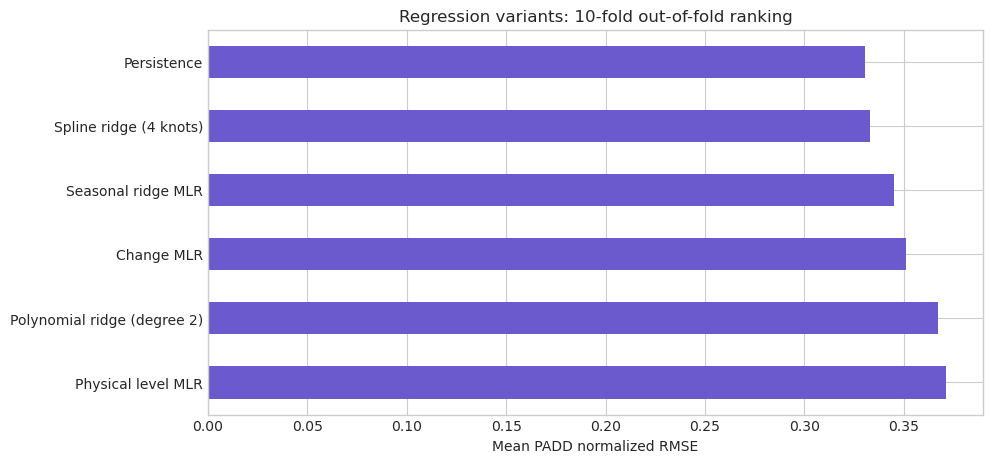

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ranking.sort_values('mean_padd_nrmse')['mean_padd_nrmse'].plot.barh(ax=ax, color='slateblue')
ax.invert_yaxis()
ax.set(title='Regression variants: 10-fold out-of-fold ranking', xlabel='Mean PADD normalized RMSE', ylabel='')
plt.show()

## Overfitting check

The test-to-train RMSE ratio highlights specifications whose apparent training fit does not generalize. Flexible polynomial and spline models should be rejected if lower training error comes with worse out-of-fold error or a materially larger gap.

In [7]:
overfit_summary = fold_diagnostics.groupby('model').agg(
    mean_train_rmse_kb=('train_rmse_kb', 'mean'),
    mean_test_rmse_kb=('test_rmse_kb', 'mean'),
).sort_values('mean_test_rmse_kb')
overfit_summary['test_to_train_rmse'] = (
    overfit_summary['mean_test_rmse_kb'] / overfit_summary['mean_train_rmse_kb']
)
overfit_summary.round(3)

,mean_train_rmse_kb,mean_test_rmse_kb,test_to_train_rmse
model,,,
Persistence,"3,580.195","4,181.832",1.168
Spline ridge (4 knots),"3,335.969","4,264.857",1.278
Seasonal ridge MLR,"3,180.468","4,295.725",1.351
Change MLR,"3,319.668","4,475.728",1.348
Physical level MLR,"3,223.940","4,841.369",1.502
Polynomial ridge (degree 2),"3,201.008","5,072.001",1.585


## Regional results

The best specification can differ by region, so the PADD-level winners and strictly out-of-fold paths are inspected separately.

In [8]:
regional_winners = (
    padd_metrics.sort_values(['padd', 'rmse_kb']).groupby('padd', as_index=False).first()
)
regional_winners[['padd', 'padd_name', 'model', 'mae_kb', 'rmse_kb', 'r2', 'nrmse']].round(3)

,padd,padd_name,model,mae_kb,rmse_kb,r2,nrmse
0,1,East Coast,Spline ridge (4 knots),"1,037.223","1,361.329",0.824,0.419
1,2,Midwest,Seasonal ridge MLR,"3,835.783","5,155.856",0.938,0.250
2,3,Gulf Coast,Persistence,"9,163.090","11,773.133",0.989,0.105
3,4,Rocky Mountain,Persistence,759.290,963.623,0.950,0.224
4,5,West Coast,Polynomial ridge (degree 2),"1,854.751","2,340.709",0.606,0.628


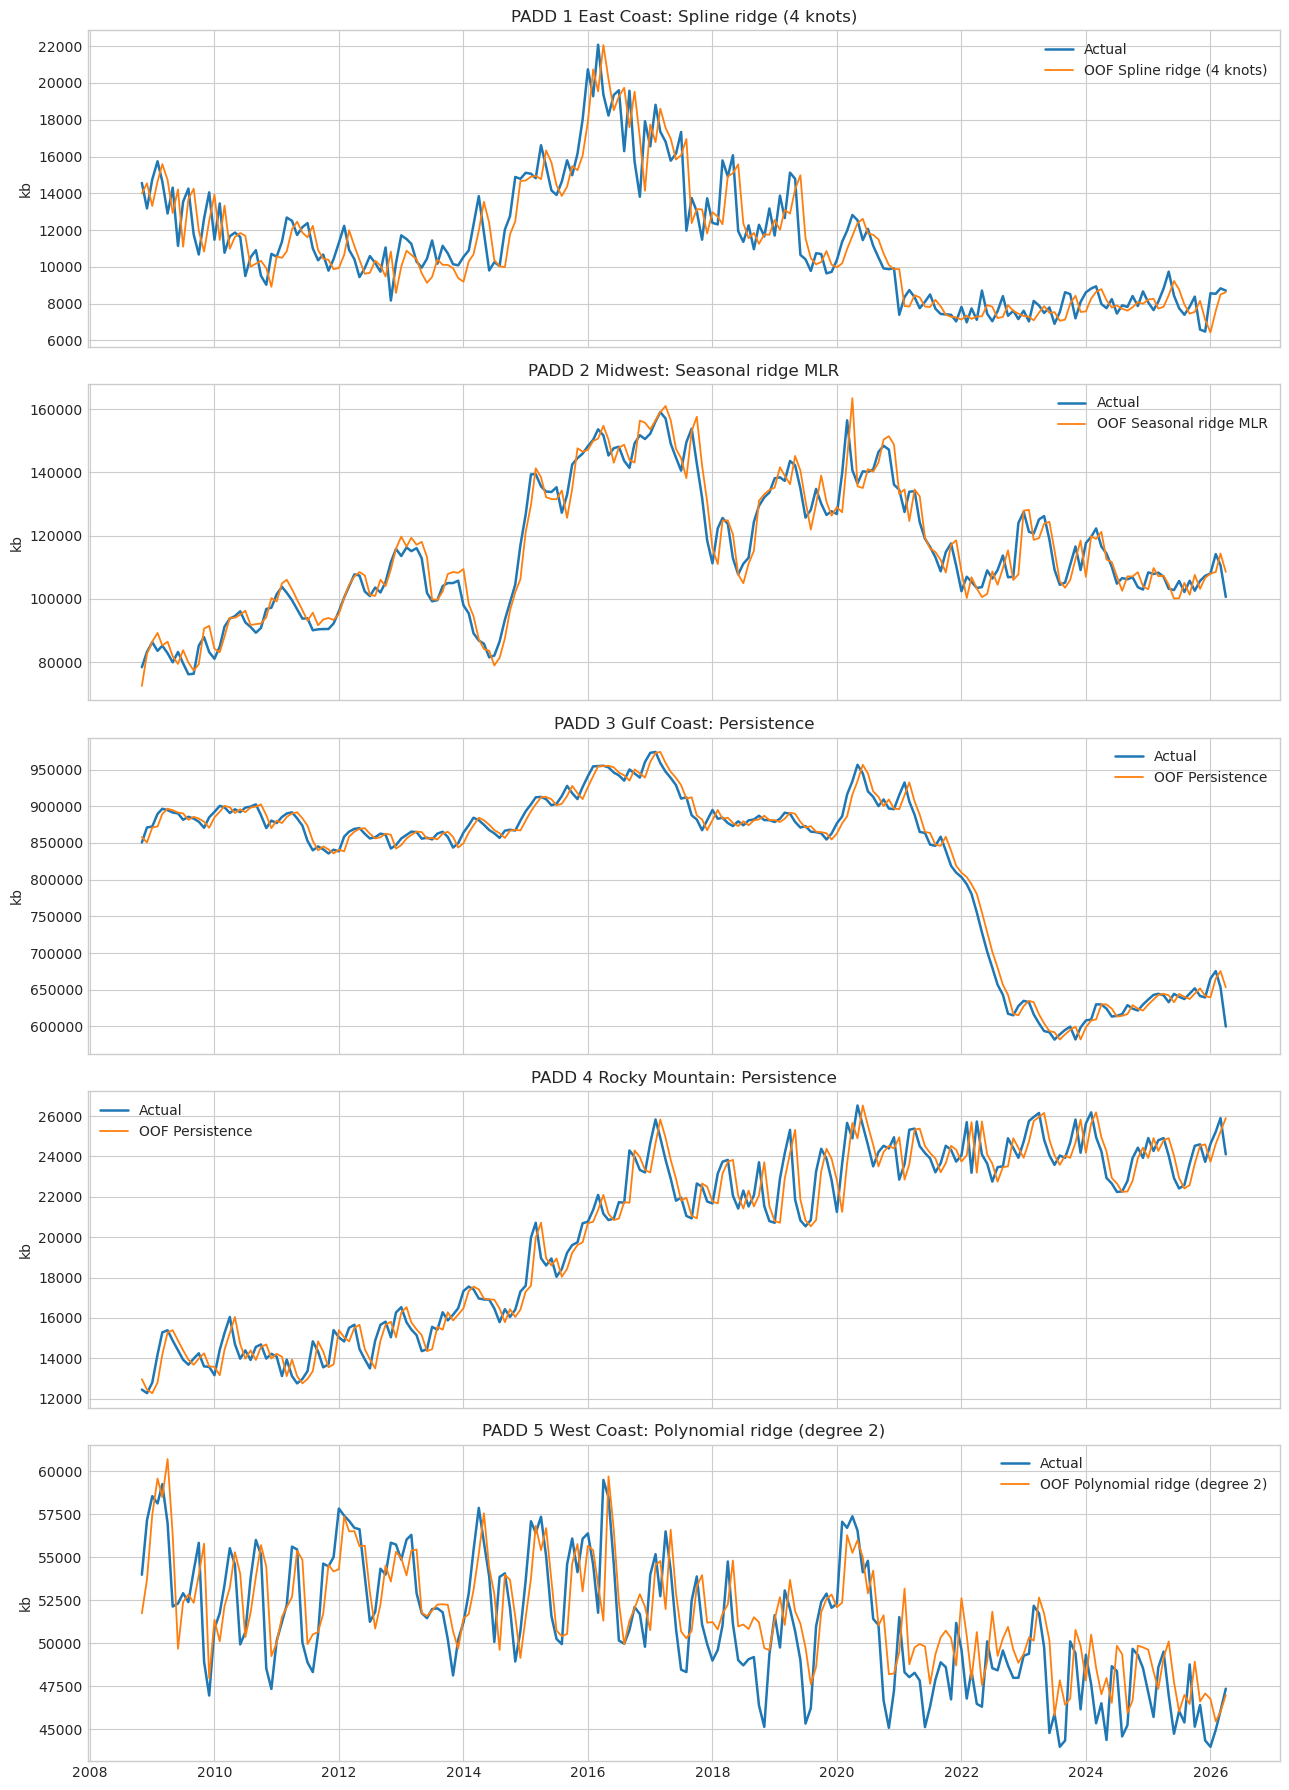

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=True)
for ax, row in zip(axes, regional_winners.itertuples(index=False)):
    view = predictions[(predictions['padd'] == row.padd) & (predictions['model'] == row.model)]
    ax.plot(view['month'], view['actual_stock_t1_kb'], label='Actual', lw=1.8)
    ax.plot(view['month'], view['prediction_kb'], label=f'OOF {row.model}', lw=1.3)
    ax.set_title(f'PADD {row.padd} {row.padd_name}: {row.model}')
    ax.set_ylabel('kb')
    ax.legend()
fig.tight_layout()
plt.show()

## Conclusion

The best fitted regression is selected by mean PADD normalized RMSE. Persistence remains separate: if it still wins overall, the notebook explicitly reports that the fitted improvement is not sufficient to justify more complexity.

In [10]:
overall_winner = ranking.index[0]
fitted_ranking = ranking.drop(index='Persistence')
fitted_winner = fitted_ranking.index[0]
best = fitted_ranking.loc[fitted_winner]
physical = ranking.loc['Physical level MLR']
persistence = ranking.loc['Persistence']
improvement = 100 * (physical['mean_padd_nrmse'] - best['mean_padd_nrmse']) / physical['mean_padd_nrmse']
gap_to_persistence = 100 * (best['mean_padd_nrmse'] - persistence['mean_padd_nrmse']) / persistence['mean_padd_nrmse']
print(f'Best overall benchmark or regression: {overall_winner}')
print(f'Best fitted regression: {fitted_winner}')
print(f"Mean PADD normalized RMSE: {best['mean_padd_nrmse']:.3f}")
print(f"Pooled out-of-fold MAE: {best['mae_kb']:,.0f} kb")
print(f"Pooled out-of-fold RMSE: {best['rmse_kb']:,.0f} kb")
print(f'Improvement versus physical level MLR: {improvement:.1f}%')
print(f'Error gap versus persistence: {gap_to_persistence:.1f}%')
if overall_winner == 'Persistence':
    print('Caution: persistence remains the strongest overall forecast, so extra regression complexity is not justified globally.')

Best overall benchmark or regression: Persistence
Best fitted regression: Spline ridge (4 knots)
Mean PADD normalized RMSE: 0.333
Pooled out-of-fold MAE: 3,453 kb
Pooled out-of-fold RMSE: 6,034 kb
Improvement versus physical level MLR: 10.4%
Error gap versus persistence: 0.7%
Caution: persistence remains the strongest overall forecast, so extra regression complexity is not justified globally.


In [11]:
output_dir = Path('regression_variants_output')
output_dir.mkdir(exist_ok=True)
predictions.to_csv(output_dir / 'out_of_fold_predictions.csv', index=False)
fold_diagnostics.to_csv(output_dir / 'fold_diagnostics.csv', index=False)
padd_metrics.to_csv(output_dir / 'padd_metrics.csv', index=False)
ranking.to_csv(output_dir / 'overall_ranking.csv')
regional_winners.to_csv(output_dir / 'regional_winners.csv', index=False)
print(f'Results written to {output_dir.resolve()}')

Results written to /home/calvin/commodities/oil/us_snd_crude/regression_variants_output


## Detailed notes on each regression specification

### Persistence reference

Persistence remains the overall benchmark winner with mean PADD NRMSE of 0.331 and pooled RMSE of 5,916 kb. It is especially strong in the Gulf Coast and Rocky Mountain regions, where it produces NRMSE values of 0.105 and 0.224. This establishes the key challenge: a regression must predict monthly stock changes better than zero while using flow data that omit important regional transfers and adjustments.

### Physical level multiple linear regression

This is the original constrained level specification: next-month stock is regressed on current stock and production, negative refinery demand, imports, and negative exports. It ranks last among the regression variants on mean PADD NRMSE at 0.371, with pooled RMSE of 7,089 kb and a test-to-train ratio of 1.50. The absolute stock term dominates, while the flow coefficients have difficulty learning omitted transfers.

Its PADD-level NRMSE ranges from 0.128 in the Gulf Coast to 0.656 on the West Coast. Although level R² remains high in the large regions, the model is worse than persistence everywhere. This is why high level R² is not sufficient evidence of forecast improvement.

### Stock-change multiple linear regression

Change MLR predicts `Stock_t+1 - Stock_t` using the signed flows and the previously observed stock change. This reframing improves mean PADD NRMSE to 0.351 and pooled RMSE to 6,388 kb. It removes the temptation for the regression to explain levels mostly through current stock and directly targets the quantity that must beat persistence. The 1.35 test-to-train ratio is also lower than the physical level model's 1.50.

The improvement is broad in PADDs 1–4, but PADD 5 deteriorates to NRMSE 0.696. This suggests that lagged changes and reported flows have some stable information in most regions, while West Coast changes are less linear or more affected by unobserved movements.

### Seasonal ridge multiple linear regression

Seasonal ridge MLR adds sine and cosine month-of-year terms to the change model and applies ridge shrinkage after fold-local scaling. It ranks third overall and second among fitted regressions, with mean PADD NRMSE of 0.345, pooled RMSE of 6,063 kb, and a test-to-train ratio of 1.35. The small gap between training and test behavior indicates that regularization is controlling the additional seasonal terms.

It is the best model in PADD 2, with RMSE of 5,156 kb and NRMSE of 0.250, narrowly beating persistence. It also nearly matches the best result in PADD 1. However, seasonality hurts PADD 5, where NRMSE rises to 0.716. A single national choice therefore trades a Midwest improvement against West Coast degradation.

### Degree-two polynomial ridge regression

The polynomial model allows squared and interaction effects among the fundamental balance, lagged stock change, and current stock. Degree is capped at two and Ridge alpha is 25, but it still has the highest fitted-model test-to-train ratio at 1.59. Mean PADD NRMSE is 0.368 and pooled RMSE is 8,145 kb, so its lower training error does not translate into better generalization.

PADD 5 is the important exception: polynomial ridge is the regional winner with RMSE of 2,341 kb and NRMSE of 0.628. This modest nonlinear gain suggests West Coast behavior may include interactions or mean reversion not captured by a linear change model. In PADD 3, however, polynomial RMSE jumps to 17,007 kb. The regional exception is not enough to justify polynomial regression as the common five-PADD model.

### Four-knot quadratic spline ridge regression

Spline ridge models smooth nonlinear responses to the fundamental balance and lagged change using only four knots and quadratic basis functions, followed by Ridge alpha 25. It is the best fitted regression: mean PADD NRMSE is 0.333, pooled MAE is 3,453 kb, and pooled RMSE is 6,034 kb. This is a 10.4% improvement over the physical level MLR and only 0.7% worse than persistence on the balanced metric. Its test-to-train ratio of 1.28 is the smallest among fitted regressions, so the improvement does not come with an excessive generalization gap.

Spline ridge wins PADD 1 with RMSE of 1,361 kb, slightly better than persistence, and remains close to persistence in PADDs 2–4. It does not win PADD 5. The low knot count appears to provide enough curvature for nonlinear balance responses without the unstable interaction surface created by polynomial regression.

### Cross-model conclusion

Changing the target from stock level to stock change is the main structural improvement. Adding regularized smooth seasonality helps further, and a low-complexity spline produces the best overall fitted result. Polynomial interactions are too unstable across regions. The evidence supports spline ridge if the goal is the strongest regression fit, while persistence remains the safest univariate forecast. A practical deployment should retain PADD-specific monitoring: seasonal ridge is strongest in PADD 2, polynomial ridge is strongest in PADD 5, and persistence remains strongest in PADDs 3 and 4. Those regional differences should be confirmed on new vintages before adopting different production models by PADD.